# Feature Engineering

Creating ensemble features from NMME forecasts, interaction features, and selecting the most informative features using mutual information.

In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../src')
from preprocess import load_data, preprocess
from features import build_features, create_nmme_ensemble_features, create_interaction_features

train_raw, test_raw = load_data('../data')
train, test = preprocess(train_raw, test_raw)
print(f"After preprocessing - Train: {train.shape}, Test: {test.shape}")

After preprocessing - Train: (375734, 267), Test: (31354, 266)


In [2]:
train = build_features(train)
test = build_features(test)
print(f"After feature engineering - Train: {train.shape}, Test: {test.shape}")

After feature engineering - Train: (375734, 279), Test: (31354, 278)


In [3]:
new_features = ['nmme_34w_mean', 'nmme_34w_std', 'nmme_34w_range',
                'nmme_56w_mean', 'nmme_56w_std', 'nmme0_mean', 'nmme0_std',
                'elev_x_nmme', 'nmme_uncertainty', 'precip_x_rhum']
for f in new_features:
    if f in train.columns:
        print(f"{f}: mean={train[f].mean():.4f}, std={train[f].std():.4f}")

nmme_34w_mean: mean=11.2014, std=10.7172
nmme_34w_std: mean=1.9125, std=0.9158
nmme_34w_range: mean=6.3335, std=3.2898
nmme_56w_mean: mean=11.0875, std=10.7792
nmme_56w_std: mean=1.9186, std=0.7852
nmme0_mean: mean=11.4831, std=10.5801
nmme0_std: mean=1.7681, std=0.5664
elev_x_nmme: mean=10610.1582, std=13970.4992
nmme_uncertainty: mean=26.8412, std=26.9967
precip_x_rhum: mean=1718.9022, std=1649.2311


In [4]:
from features import select_features
target_col = 'contest-tmp2m-14d__tmp2m'

# Use a sample for MI computation (375K rows is too slow for full MI)
train_sample = train.sample(n=50000, random_state=42)
selected = select_features(train_sample, target_col, top_k=150)
print(f"Selected {len(selected)} features")
print("Top 20:", selected[:20])

Selected 150 features
Top 20: ['nmme-tmp2m-56w__cfsv2', 'nmme-tmp2m-34w__cfsv2', 'nmme-tmp2m-56w__gfdlflora', 'nmme-tmp2m-34w__gfdlflorb', 'nmme-tmp2m-56w__nmmemean', 'nmme_56w_mean', 'nmme_34w_mean', 'nmme-tmp2m-34w__nmmemean', 'nmme-tmp2m-56w__gfdlflorb', 'nmme-tmp2m-34w__gfdlflora', 'nmme_34w_min', 'nmme_34w_max', 'nmme-tmp2m-34w__ccsm4', 'nmme-tmp2m-56w__ccsm4', 'nmme-tmp2m-56w__nasa', 'nmme-tmp2m-34w__gfdl', 'nmme-tmp2m-56w__gfdl', 'nmme-tmp2m-34w__nasa', 'nmme-tmp2m-34w__cancm3', 'nmme-tmp2m-56w__cancm3']


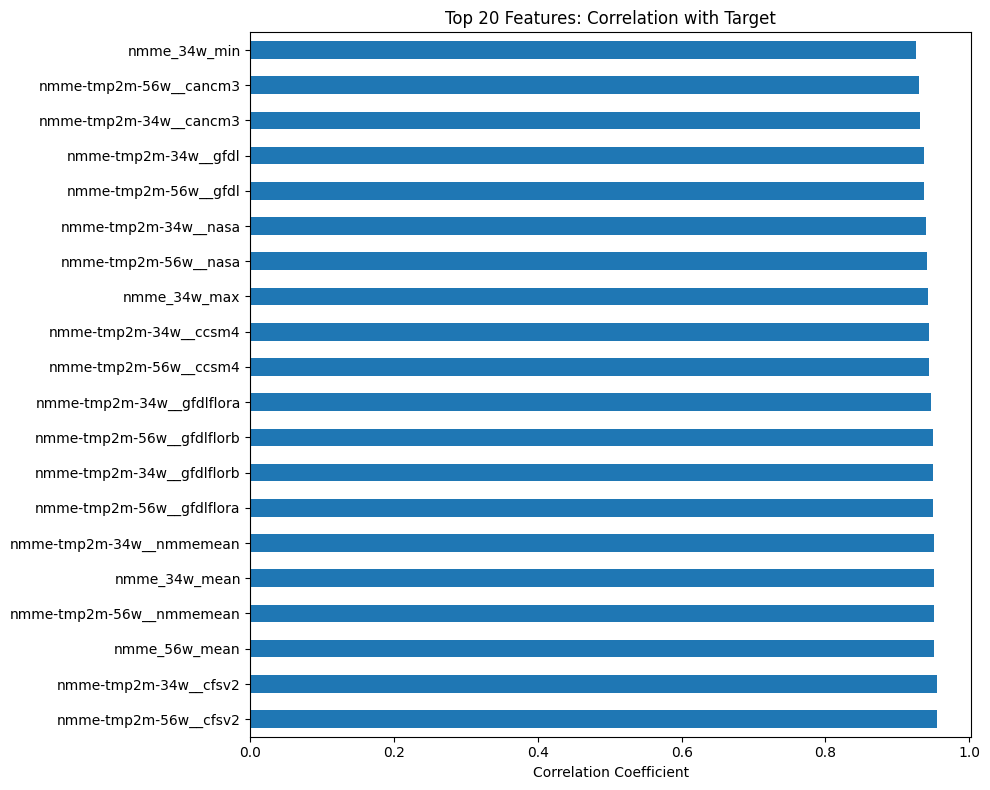

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = selected[:20]
corr_with_target = train_sample[top_features + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.plot(kind='barh', ax=ax)
ax.set_title('Top 20 Features: Correlation with Target')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [6]:
missing_after = train[selected].isnull().sum()
print(f"Features with missing values after engineering: {(missing_after > 0).sum()}")
if (missing_after > 0).sum() > 0:
    print(missing_after[missing_after > 0])

Features with missing values after engineering: 7
nmme-tmp2m-56w__ccsm3      10280
nmme-tmp2m-34w__ccsm3       8738
nmme0-tmp2m-34w__ccsm30    15934
ccsm30                     15934
nmme0-prate-34w__ccsm30    15934
nmme-prate-34w__ccsm3       8738
nmme-prate-56w__ccsm3      10280
dtype: int64


In [7]:
import json
with open('../outputs/portfolio_data/selected_features.json', 'w') as f:
    json.dump({'selected_features': selected, 'count': len(selected)}, f)
print(f"Saved {len(selected)} selected features")

Saved 150 selected features
